# IN403 – Unit 1 Lab: Predicting Hospital No‑Shows (PyTorch + HuggingFace)

**Goal:** Build a baseline model and a small neural network to predict whether a patient will miss an appointment.

## What you will submit
1. This completed notebook (exported as `.ipynb`)
2. A short decision memo (≈ 1 page) answering:
   - Which model would you recommend to the hospital and why?
   - How do you balance accuracy vs interpretability vs operational risk?

## Dataset
Use the provided file: `hospital_no_show_synthetic.csv` (uploaded with this lab).


## 0) Setup
Run this cell first to install/import packages.


In [3]:
# If running in Colab, uncomment installs:
# !pip -q install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# !pip -q install scikit-learn pandas matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


## 1) Load and inspect the data

**Student task:**
- Load the CSV
- Display 5 rows
- Print basic info (columns, missing values)
- Identify the target column


In [4]:
df = pd.read_csv('hospital_no_show_synthetic.csv')
display(df.head())
print(df.shape)
df.info()
print('\nMissing values:\n', df.isna().sum())
target_col = 'no_show'


,age,appointment_type,clinic,insurance_type,lead_days,prior_no_show_count,distance_km,day_of_week,hour_of_day,sms_opt_in,reminder_days_before,temp_f,precip_in,no_show
0,24,Primary Care,East,Medicaid,10,1,9.02,1,12,1,3,92.8,0.02,0
1,73,Primary Care,South,Medicare,9,0,5.38,6,11,0,4,67.1,0.01,0
2,65,Imaging,South,Medicare,22,0,4.06,6,16,1,2,70.8,0.06,0
3,49,Lab,East,Private,22,0,5.23,0,9,1,0,73.8,0.04,0
4,49,Primary Care,North,Medicaid,9,1,5.04,4,15,1,1,57.1,0.14,0


(5000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   5000 non-null   int64  
 1   appointment_type      5000 non-null   str    
 2   clinic                5000 non-null   str    
 3   insurance_type        5000 non-null   str    
 4   lead_days             5000 non-null   int64  
 5   prior_no_show_count   5000 non-null   int64  
 6   distance_km           5000 non-null   float64
 7   day_of_week           5000 non-null   int64  
 8   hour_of_day           5000 non-null   int64  
 9   sms_opt_in            5000 non-null   int64  
 10  reminder_days_before  5000 non-null   int64  
 11  temp_f                5000 non-null   float64
 12  precip_in             5000 non-null   float64
 13  no_show               5000 non-null   int64  
dtypes: float64(3), int64(8), str(3)
memory usage: 547.0 KB

Missing values:


## 2) Quick EDA (Exploratory Data Analysis)

**Student task:** Create at least 2 plots:
- Distribution of `lead_days`
- No-show rate by appointment type (bar chart)


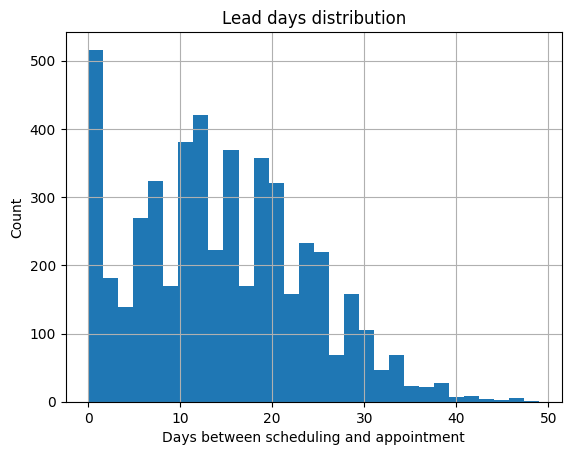

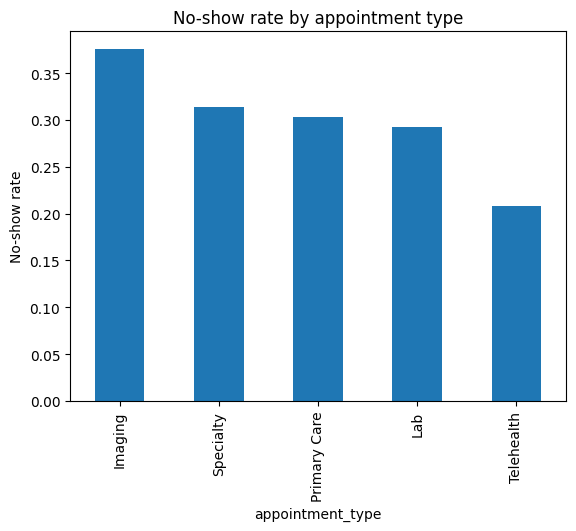

In [5]:
plt.figure()
df['lead_days'].hist(bins=30)
plt.title('Lead days distribution')
plt.xlabel('Days between scheduling and appointment')
plt.ylabel('Count')
plt.show()

plt.figure()
noshow_rate = df.groupby('appointment_type')[target_col].mean().sort_values(ascending=False)
noshow_rate.plot(kind='bar')
plt.title('No-show rate by appointment type')
plt.ylabel('No-show rate')
plt.show()


## 3) Train/test split + preprocessing

**Student task:**
- Split into train/test sets
- Identify categorical vs numeric columns
- Build a preprocessing pipeline using `ColumnTransformer`


In [6]:
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

cat_cols = ['appointment_type', 'clinic', 'insurance_type']
num_cols = [c for c in X.columns if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)


## 4) Baseline model: Logistic Regression

**Student task:**
- Train logistic regression
- Report Accuracy, Precision, Recall, F1, ROC-AUC
- Show a confusion matrix


Baseline metrics: {'accuracy': 0.709, 'precision': 0.5727272727272728, 'recall': 0.20521172638436483, 'f1': 0.302158273381295, 'roc_auc': 0.6941541990401925}


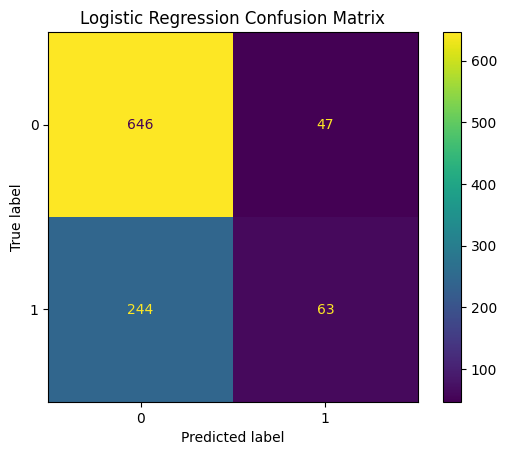

In [7]:
baseline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=2000))
])

baseline.fit(X_train, y_train)
pred = baseline.predict(X_test)
proba = baseline.predict_proba(X_test)[:, 1]

metrics = {
    'accuracy': accuracy_score(y_test, pred),
    'precision': precision_score(y_test, pred),
    'recall': recall_score(y_test, pred),
    'f1': f1_score(y_test, pred),
    'roc_auc': roc_auc_score(y_test, proba)
}
print('Baseline metrics:', metrics)

cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Logistic Regression Confusion Matrix')
plt.show()


## 5) Prepare tensors for PyTorch

**Student task:**
- Fit the preprocessing transformer on training data
- Transform train/test features into numeric matrices
- Convert to PyTorch tensors


In [8]:
# Fit transformer on training data only
X_train_p = preprocess.fit_transform(X_train)
X_test_p = preprocess.transform(X_test)

X_train_t = torch.tensor(X_train_p.toarray() if hasattr(X_train_p, 'toarray') else X_train_p, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_p.toarray()  if hasattr(X_test_p, 'toarray')  else X_test_p,  dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_t  = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

X_train_t.shape, y_train_t.shape


(torch.Size([4000, 24]), torch.Size([4000, 1]))

## 6) Build a simple neural network

**Requirements:**
- Feed-forward network
- 2 hidden layers
- ReLU activations
- Dropout (0.2)
- Output layer with Sigmoid (binary classification)

**Student task:** Complete the model class and confirm the output shape.


In [9]:
input_dim = X_train_t.shape[1]

class NoShowNet(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

model = NoShowNet(input_dim)
with torch.no_grad():
    print(model(X_train_t[:5]).shape)


torch.Size([5, 1])


## 7) Train the model

**Student task:**
- Use `BCELoss` (binary cross-entropy)
- Use Adam optimizer
- Train for 15 epochs
- Track training loss and validation loss
- Plot both curves


Epoch 5/15 | train_loss=0.6604 | val_loss=0.6569
Epoch 10/15 | train_loss=0.6455 | val_loss=0.6420
Epoch 15/15 | train_loss=0.6317 | val_loss=0.6289


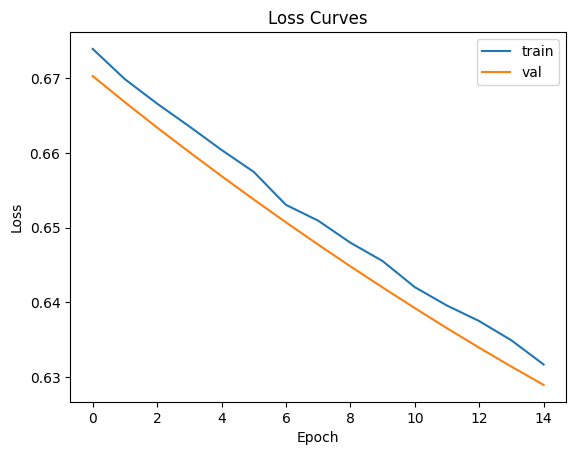

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

X_train_t_d = X_train_t.to(device)
y_train_t_d = y_train_t.to(device)
X_test_t_d  = X_test_t.to(device)
y_test_t_d  = y_test_t.to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_losses, val_losses = [], []
epochs = 15

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train_t_d)
    loss = criterion(y_pred, y_train_t_d)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        y_val = model(X_test_t_d)
        val_loss = criterion(y_val, y_test_t_d)
        val_losses.append(val_loss.item())

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} | train_loss={loss.item():.4f} | val_loss={val_loss.item():.4f}")

plt.figure()
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


## 8) Evaluate the neural network

**Student task:**
- Compute Accuracy, Precision, Recall, F1, ROC-AUC
- Create a confusion matrix
- Compare results against logistic regression in a single table


Neural net metrics: {'accuracy': 0.693, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc_auc': 0.5175392830115957}


/Users/L037129/Desktop/Apprenticeship/Data Science 2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


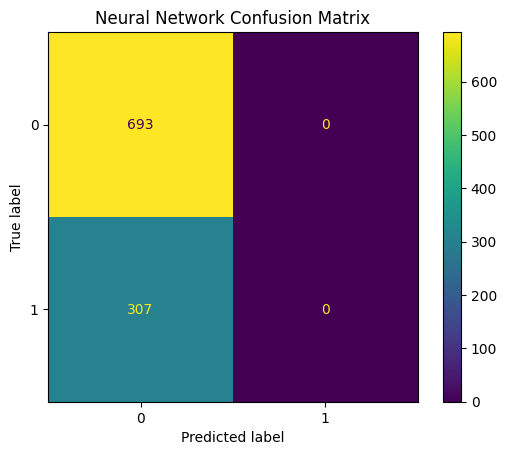

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.709,0.572727,0.205212,0.302158,0.694154
1,Neural Network,0.693,0.000000,0.000000,0.000000,0.517539


In [11]:
model.eval()
with torch.no_grad():
    probs = model(X_test_t_d).cpu().numpy().ravel()

preds = (probs >= 0.5).astype(int)

nn_metrics = {
    'accuracy': accuracy_score(y_test, preds),
    'precision': precision_score(y_test, preds),
    'recall': recall_score(y_test, preds),
    'f1': f1_score(y_test, preds),
    'roc_auc': roc_auc_score(y_test, probs)
}
print('Neural net metrics:', nn_metrics)

cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm).plot()
plt.title('Neural Network Confusion Matrix')
plt.show()

compare = pd.DataFrame([
    {'model': 'Logistic Regression', **metrics},
    {'model': 'Neural Network', **nn_metrics}
])
display(compare)


## 9) Reflection questions (answer in markdown)

1. Which model would you deploy at the hospital and why?
2. Did the neural network meaningfully outperform the baseline? If yes, *how much* improvement did you see?
3. What is one risk of using a black-box model in healthcare operations?
4. If the hospital demanded interpretability, what would you change?


### Optional AI Extension (bonus)

Use a HuggingFace **tabular model** or explainability tool (e.g., SHAP) to explain feature importance and write 1 paragraph interpreting the top drivers of no-shows.
